In [37]:
library(lme4)
library(emmeans)
library(dplyr)
library(afex)


setwd("C:/Users/jacob/water_current_MA/data/dual_generalization")
dir <- getwd()
print(paste("Working directory:", dir))


df_full <- read.csv("PCA_error_projectile_experiment _S1-projectile_experiment_S2-projectile_experiment_S1_3.0M-projectile_experiment 1_S2_3.0M-projectile_experiment 1_speed_neg3_0_neg2_0_0_0.csv")

df_full$ppid_full <- factor(df_full$ppid_full)
df_full$speed_label <- factor(df_full$speed_label)
df_full$target_x_label <- factor(df_full$target_x_label)
df_full$phase <- factor(df_full$phase)

[1] "Working directory: C:/Users/jacob/water_current_MA/data/dual_generalization"


In [ ]:
#### GENERALIZATION ANALYSIS

[1] "-2"


Contrasts set to contr.sum for the following variables: target_x_label, phase, ppid_full



Mixed Model Anova Table (Type 3 tests, S-method)

Model: PCA_error_X_cm_bc ~ target_x_label * phase + (1 | ppid_full)
Data: df_subset
                Effect        df         F p.value
1       target_x_label 3, 523.67 50.56 ***   <.001
2                phase 1, 523.96 31.80 ***   <.001
3 target_x_label:phase 3, 120.43    2.18 +    .093
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


NOTE: Results may be misleading due to involvement in interactions



 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -11.9 2.11 524      -16    -7.74  -5.639  <.0001

Results are averaged over the levels of: target_x_label 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 
target_x_label = L30:
 contrast                estimate   SE    df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -5.34 5.59  99.9    -16.4     5.76  -0.955  0.3419

target_x_label = L60:
 contrast                estimate   SE    df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -8.18 5.59  99.7    -19.3     2.91  -1.463  0.1466

target_x_label = R30:
 contrast                estimate   SE    df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -15.14 5.61 101.0    -26.3    -4.00  -2.697  0.0082

target_x_label = R60:
 contrast                estimate   SE    df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -18.86 5.56  97.5    -29.9    -7.84  -3.395  0

Contrasts set to contr.sum for the following variables: target_x_label, phase, ppid_full



Mixed Model Anova Table (Type 3 tests, S-method)

Model: PCA_error_X_cm_bc ~ target_x_label * phase + (1 | ppid_full)
Data: df_subset
                Effect        df          F p.value
1       target_x_label 3, 511.01  99.27 ***   <.001
2                phase 1, 512.12 169.77 ***   <.001
3 target_x_label:phase 3, 110.91   5.84 ***   <.001
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


NOTE: Results may be misleading due to involvement in interactions



 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -26.3 2.02 512    -30.3    -22.3 -13.028  <.0001

Results are averaged over the levels of: target_x_label 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 
target_x_label = L30:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -20.4 5.88 80.5    -32.1    -8.71  -3.472  0.0008

target_x_label = L60:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -16.4 5.88 80.7    -28.1    -4.67  -2.784  0.0067

target_x_label = R30:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -38.0 5.94 83.5    -49.8   -26.24  -6.409  <.0001

target_x_label = R60:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -30.4 5.88 80.8    -42.1   -18.70  -5.169  <.0001

D

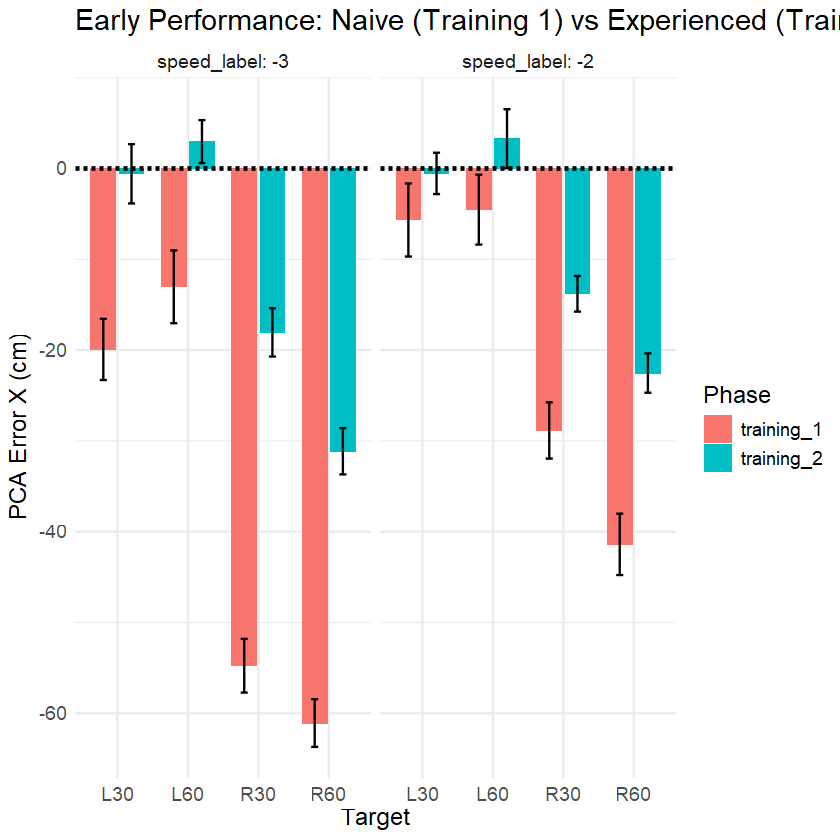

In [39]:
library(afex)
library(emmeans) 


df_early_late <- read.csv("early_late_phase_PCA_error_projectile_experiment _S1-projectile_experiment_etc_speed_neg3_0_neg2_0.csv")

# Ensure factors
df_early_late$ppid_full <- factor(df_early_late$ppid_full)
df_early_late$speed_label <- factor(df_early_late$speed_label)
df_early_late$target_x_label <- factor(df_early_late$target_x_label)
df_early_late$phase <- factor(df_early_late$phase)
df_early_late$trial_set <- factor(df_early_late$trial_set)



# leave out late trials
df_early <- df_early_late[df_early_late$trial_set == "early", ]
speeds_list <- unique(df_early$speed_label)

for (s in speeds_list) {

  print(s)
  
  df_subset <- df_early[df_early$speed_label == s,]
  df_subset <- droplevels(df_subset) 
    
  mm_gen <- afex::mixed(PCA_error_X_cm_bc ~ target_x_label * phase + (1|ppid_full),
                        data = df_subset, method = "S")
  
  print(afex::nice(mm_gen))
  
  emm_mm_gen <- emmeans(mm_gen, ~ phase)
  emm_by_target <- emmeans(mm_gen, ~ phase | target_x_label)
  
  print(pairs(emm_mm_gen, infer = TRUE))
  print(pairs(emm_by_target, adjust = "holm", infer = TRUE))
}


library(ggplot2)
library(dplyr)

# Calculate means and standard errors for plotting
plot_data <- df_early %>%
  group_by(speed_label, phase, target_x_label) %>%
  summarise(
    mean_error = mean(PCA_error_X_cm_bc, na.rm = TRUE),
    se_error = sd(PCA_error_X_cm, na.rm = TRUE) / sqrt(n()),
    .groups = "drop"
  )

# Create the plot
ggplot(plot_data, aes(x = target_x_label, y = mean_error, fill = phase)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.7) +
  geom_errorbar(aes(ymin = mean_error - se_error, ymax = mean_error + se_error),
                position = position_dodge(width = 0.8), width = 0.2) +
  facet_wrap(~ speed_label, labeller = label_both) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 1) + # 0 line
  theme_minimal() +
  labs(
    title = "Early Performance: Naive (Training 1) vs Experienced (Training 2)",
    x = "Target",
    y = "PCA Error X (cm)",
    fill = "Phase"
  ) +
  theme(text = element_text(size = 14))

In [ ]:
# OVERALL LEARNING (EARLY VS LATE) ANALYSIS

[1] "Working directory: C:/Users/jacob/water_current_MA/data/dual_generalization"
[1] "-2"


Contrasts set to contr.sum for the following variables: target_x_label, phase, trial_set, ppid_full



Mixed Model Anova Table (Type 3 tests, S-method)

Model: PCA_error_X_cm_bc ~ target_x_label * phase * trial_set + (1 | 
Model:     ppid_full)
Data: df_subset
                          Effect         df         F p.value
1                 target_x_label 3, 1087.35 73.54 ***   <.001
2                          phase 1, 1087.43 13.71 ***   <.001
3                      trial_set 1, 1087.44 33.38 ***   <.001
4           target_x_label:phase  3, 122.32   4.39 **    .006
5       target_x_label:trial_set 3, 1087.37  7.82 ***   <.001
6                phase:trial_set 1, 1087.50 27.27 ***   <.001
7 target_x_label:phase:trial_set 3, 1087.35      0.93    .427
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions



 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -4.89 1.32 1087    -7.48     -2.3  -3.702  0.0002

Results are averaged over the levels of: target_x_label, trial_set 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 
target_x_label = L30:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -1.88 3.68 90.1    -9.19    5.420  -0.512  0.6097

target_x_label = L60:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2     1.55 3.67 89.7    -5.75    8.840   0.421  0.6748

target_x_label = R30:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -7.82 3.68 90.0   -15.13   -0.524  -2.129  0.0360

target_x_label = R60:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -11.40 3.66 88.8   -18.67   -4.120  -3.1

Contrasts set to contr.sum for the following variables: target_x_label, phase, trial_set, ppid_full



Mixed Model Anova Table (Type 3 tests, S-method)

Model: PCA_error_X_cm_bc ~ target_x_label * phase * trial_set + (1 | 
Model:     ppid_full)
Data: df_subset
                          Effect         df          F p.value
1                 target_x_label 3, 1091.24 162.57 ***   <.001
2                          phase 1, 1091.51 120.36 ***   <.001
3                      trial_set 1, 1091.45  78.80 ***   <.001
4           target_x_label:phase  3, 106.12   7.49 ***   <.001
5       target_x_label:trial_set 3, 1091.23   9.38 ***   <.001
6                phase:trial_set 1, 1091.49  87.01 ***   <.001
7 target_x_label:phase:trial_set 3, 1091.22     2.99 *    .030
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions



 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -14.1 1.29 1092    -16.6    -11.6 -10.971  <.0001

Results are averaged over the levels of: target_x_label, trial_set 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 
target_x_label = L30:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -10.58 4.73 57.5    -20.1    -1.11  -2.236  0.0292

target_x_label = L60:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -5.62 4.73 57.4    -15.1     3.85  -1.188  0.2396

target_x_label = R30:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -19.35 4.74 58.0    -28.8    -9.85  -4.077  0.0001

target_x_label = R60:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -20.92 4.73 57.5    -30.4   -11.44  -4.4

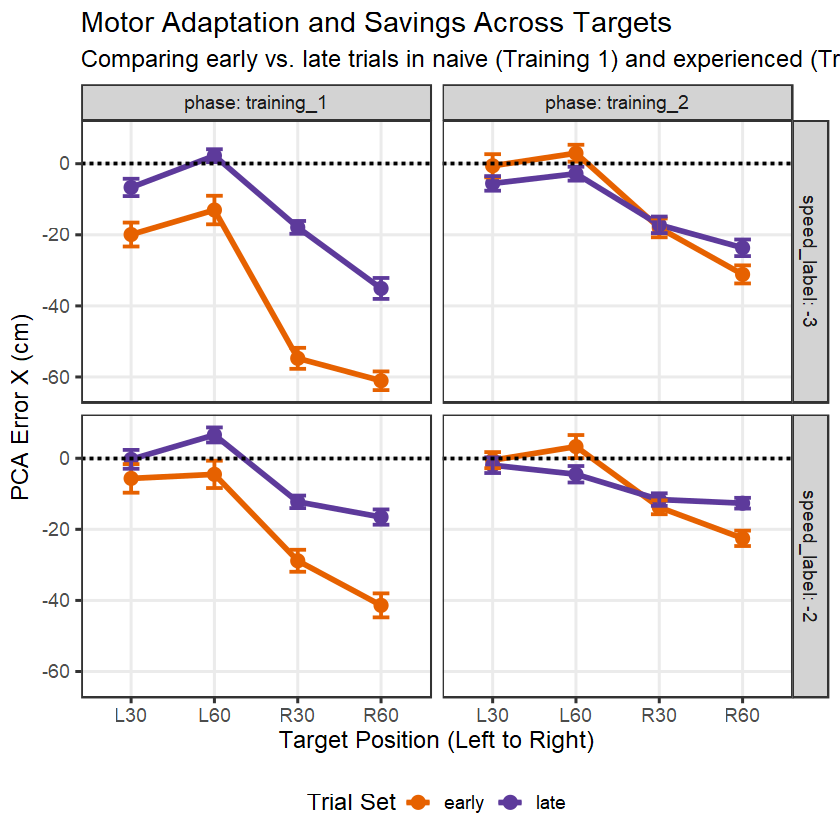

In [47]:
library(afex)
library(emmeans) 

setwd("C:/Users/jacob/water_current_MA/data/dual_generalization")
dir <- getwd()
print(paste("Working directory:", dir))

speeds_list <- unique(df_early$speed_label)


for (s in speeds_list) {
  
  print(s)
  
  df_subset <- df_early_late[df_early_late$speed_label == s,]
  df_subset <- droplevels(df_subset) 
    
  mm_gen <- afex::mixed(PCA_error_X_cm_bc ~ target_x_label * phase * trial_set + (1|ppid_full),
                        data = df_subset, method = "S")
  
  print(afex::nice(mm_gen))
  
  emm_mm_gen <- emmeans(mm_gen, ~ phase)
  emm_by_set <- emmeans(mm_gen, ~ trial_set)
  emm_by_target <- emmeans(mm_gen, ~ phase | target_x_label)
  emm_phase_trial <- emmeans(mm_gen, ~ trial_set | phase)
  emm_3way <- emmeans(mm_gen, ~ trial_set | phase * target_x_label)
  
  print(pairs(emm_mm_gen, infer = TRUE))
  print(pairs(emm_by_target, adjust = "holm", infer = TRUE))
  print(pairs(emm_by_set, adjust = "holm", infer = TRUE))
  print(pairs(emm_3way, adjust = "holm", infer = TRUE))

}

# GENERATE THE PLOTS ---

# Calculate means and standard errors
plot_data <- df_early_late %>%
  group_by(speed_label, phase, trial_set, target_x_label) %>%
  summarise(
    mean_error = mean(PCA_error_X_cm_bc, na.rm = TRUE),
    se_error = sd(PCA_error_X_cm, na.rm = TRUE) / sqrt(n()),
    .groups = "drop"
  )

# Create the 3-Way Interaction Plot
adaptation_plot <- ggplot(plot_data, aes(x = target_x_label, y = mean_error, color = trial_set, group = trial_set)) +
  # Draw the lines connecting early to late
  geom_line(linewidth = 1.2) +
  # Add the points with error bars
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = mean_error - se_error, ymax = mean_error + se_error), width = 0.2, linewidth = 0.8) +
  # Create a grid: Speeds on the Y axis, Phases on the X axis
  facet_grid(speed_label ~ phase, labeller = label_both) + 
  # Add the "perfect aim" baseline
  geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 0.8) +
  # Clean up the theme
  theme_bw(base_size = 14) +
  scale_color_manual(values = c("early" = "#E66100", "late" = "#5D3A9B")) +
  labs(
    title = "Motor Adaptation and Savings Across Targets",
    subtitle = "Comparing early vs. late trials in naive (Training 1) and experienced (Training 2) phases",
    x = "Target Position (Left to Right)", 
    y = "PCA Error X (cm)", 
    color = "Trial Set"
  ) +
  theme(
    legend.position = "bottom",
    strip.background = element_rect(fill = "lightgray"),
    panel.grid.minor = element_blank()
  )

# Display the plot
print(adaptation_plot)


In [ ]:
### WASHOUT ANALYSIS

In [13]:
names(df_full)

[1] "experiment"               "ppid_full"               
 [3] "speed_label"              "target_x_label"          
 [5] "target_position_x_cm"     "target_position_z_cm"    
 [7] "trial_num"                "phase"                   
 [9] "phase_target_trial_num"   "trial_num_target"        
[11] "cycle_target_num"         "cycle_TargetxPhase_num"  
[13] "launch_deviation"         "launch_Speed"            
[15] "ball_dist_to_center_cm"   "lateral_error_x_cm"      
[17] "depth_error_z_cm"         "target_hit"              
[19] "water_speed_binary"       "water_speed_m_s"         
[21] "sign_label"               "set_order"               
[23] "min_pos_from_target_x_cm" "min_pos_from_target_z_cm"
[25] "target_angle_90"          "pc_vector_1_angle"       
[27] "pc_vector_1_pca_center_x" "pc_vector_1_pca_center_z"
[29] "pc_vector_1_c_X"          "pc_vector_1_c_Z"         
[31] "pc_rad"                   "centered_x"              
[33] "centered_z"               "unrotated_x"             
[35] "unrotated_z"              "tgt_centered_x"          
[37] "tgt_centered_z"           "tgt_unrotated_x"         
[39] "tgt_unrotated_z"          "PCA_error_X_cm"          
[41] "PCA_error_Z_cm"           "PCA_error_X_cm_mean"     
[43] "PCA_error_X_cm_bc"

In [11]:
library(afex)
library(emmeans) 

setwd("C:/Users/jacob/water_current_MA/data/dual_generalization")
dir <- getwd()
print(paste("Working directory:", dir))

df_washout <- df_full[df_full$phase == 'washout_1' | df_full$phase == 'washout_2' & df_full$water_speed_binary == 0, ]

speeds_list <- unique(df_washout$speed_label)


for (s in speeds_list) {

  print(s)
  
  df_subset <- df_washout[df_washout$speed_label == s,]
  df_subset <- droplevels(df_subset)
  
  df_subset <- df_subset %>% mutate(trial_centered = phase_target_trial_num - 1)
    
  mm_gen <- afex::mixed(lateral_error_x_cm ~ target_x_label * phase + (1|ppid_full),
                        data = df_subset, method = "S")
  
  print(afex::nice(mm_gen))
  
  emm_mm_gen <- emmeans(mm_gen, ~ phase)
  emm_by_target <- emmeans(mm_gen, ~ phase | target_x_label)
  
  print(pairs(emm_mm_gen, infer = TRUE))
  print(pairs(emm_by_target, adjust = "holm", infer = TRUE))

}


[1] "Working directory: C:/Users/jacob/water_current_MA/data/dual_generalization"
[1] "-2"


Contrasts set to contr.sum for the following variables: target_x_label, phase, ppid_full



Mixed Model Anova Table (Type 3 tests, S-method)

Model: lateral_error_x_cm ~ target_x_label * phase + (1 | ppid_full)
Data: df_subset
                Effect         df         F p.value
1       target_x_label 3, 3982.94 25.19 ***   <.001
2                phase 1, 3982.95 16.23 ***   <.001
3 target_x_label:phase  3, 126.40  9.59 ***   <.001
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 4025' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 4025)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 4025' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 4025)' or larger];
but be warned that this may result in large computation time and memory use.

NOTE: Results may be misleading due to involvement in interactions

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 4025' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 4025)' or larger];
but be warned that this may result in large computation time and mem

 contrast              estimate    SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2    -2.17 0.538 Inf     -3.22     -1.11  -4.028  0.0001

Results are averaged over the levels of: target_x_label 
Degrees-of-freedom method: asymptotic 
Confidence level used: 0.95 
target_x_label = L30:
 contrast              estimate   SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2     2.16 1.54 Inf    -0.862      5.18   1.401  0.1613

target_x_label = L60:
 contrast              estimate   SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2    -1.08 1.55 Inf    -4.123      1.97  -0.694  0.4875

target_x_label = R30:
 contrast              estimate   SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2    -7.42 1.55 Inf   -10.465     -4.37  -4.774  <.0001

target_x_label = R60:
 contrast              estimate   SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2    -2.32 1.54 Inf    -5.344      0.70  -1.506  0.1321

Degrees-of

Contrasts set to contr.sum for the following variables: target_x_label, phase, ppid_full



Mixed Model Anova Table (Type 3 tests, S-method)

Model: lateral_error_x_cm ~ target_x_label * phase + (1 | ppid_full)
Data: df_subset
                Effect         df         F p.value
1       target_x_label 3, 3979.02 75.62 ***   <.001
2                phase 1, 3979.03 49.27 ***   <.001
3 target_x_label:phase  3, 144.30 22.99 ***   <.001
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 4021' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 4021)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 4021' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 4021)' or larger];
but be warned that this may result in large computation time and memory use.

NOTE: Results may be misleading due to involvement in interactions

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 4021' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 4021)' or larger];
but be warned that this may result in large computation time and mem

 contrast              estimate    SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2    -3.74 0.533 Inf     -4.79      -2.7  -7.019  <.0001

Results are averaged over the levels of: target_x_label 
Degrees-of-freedom method: asymptotic 
Confidence level used: 0.95 
target_x_label = L30:
 contrast              estimate   SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2    -1.37 1.43 Inf     -4.16      1.43  -0.958  0.3380

target_x_label = L60:
 contrast              estimate   SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2     2.44 1.39 Inf     -0.28      5.16   1.758  0.0787

target_x_label = R30:
 contrast              estimate   SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2    -5.43 1.39 Inf     -8.15     -2.71  -3.912  0.0001

target_x_label = R60:
 contrast              estimate   SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2   -10.61 1.43 Inf    -13.41     -7.81  -7.436  <.0001

Degrees-of

In [167]:
df_subset

,experiment,ppid_full,speed_label,target_x_label,target_position_x_cm,target_position_z_cm,trial_num,phase,phase_target_trial_num,trial_num_target,⋯,unrotated_z,tgt_centered_x,tgt_centered_z,tgt_unrotated_x,tgt_unrotated_z,PCA_error_X_cm,PCA_error_Z_cm,PCA_error_X_cm_mean,PCA_error_X_cm_bc,trial_centered
,<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<int>,<fct>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
17241,S1_3.0M-projectile_experiment 1,1_neg3,-3,L60,-60,140,203,washout_1,1,89,⋯,122.6635315,-8.9352781,5.019826,9.226709,-4.461580,-82.4697131,127.1251110,0.9369059,-83.406619,0
17242,S1_3.0M-projectile_experiment 1,1_neg3,-3,R30,30,140,204,washout_1,1,89,⋯,-2.9278575,-6.7015013,7.220195,9.044805,-3.902927,-34.8081681,0.9750694,-11.8490010,-22.959167,0
17243,S1_3.0M-projectile_experiment 1,1_neg3,-3,L60,-60,140,205,washout_1,2,90,⋯,-7.7250309,-8.9352781,5.019826,9.226709,-4.461580,-31.3580677,-3.2634514,0.9369059,-32.294974,1
17244,S1_3.0M-projectile_experiment 1,1_neg3,-3,R30,30,140,206,washout_1,2,90,⋯,-2.8258314,-6.7015013,7.220195,9.044805,-3.902927,-36.1071293,1.0770955,-11.8490010,-24.258128,1
17245,S1_3.0M-projectile_experiment 1,1_neg3,-3,L60,-60,140,207,washout_1,3,91,⋯,2.0772273,-8.9352781,5.019826,9.226709,-4.461580,9.8160421,6.5388068,0.9369059,8.879136,2
17246,S1_3.0M-projectile_experiment 1,1_neg3,-3,R30,30,140,208,washout_1,3,91,⋯,-4.0672169,-6.7015013,7.220195,9.044805,-3.902927,-28.5412807,-0.1642899,-11.8490010,-16.692280,2
17247,S1_3.0M-projectile_experiment 1,1_neg3,-3,R30,30,140,209,washout_1,4,92,⋯,3.0808826,-6.7015013,7.220195,9.044805,-3.902927,4.7808211,6.9838095,-11.8490010,16.629822,3
17248,S1_3.0M-projectile_experiment 1,1_neg3,-3,L60,-60,140,210,washout_1,4,92,⋯,-7.2654233,-8.9352781,5.019826,9.226709,-4.461580,-36.6035973,-2.8038438,0.9369059,-37.540503,3
17249,S1_3.0M-projectile_experiment 1,1_neg3,-3,L60,-60,140,211,washout_1,5,93,⋯,-0.6461122,-0.6243195,5.082745,4.338009,2.721351,-16.4115901,-3.3674627,0.9369059,-17.348496,4
